In [1]:
import pandas as pd
import numpy as np

# --- Step 1: Load Data ---
df = pd.read_csv("/Users/anamikasaroha/Energy7/week_10/NFR_poll_20.csv")

In [10]:
df.shape

(9865, 12)

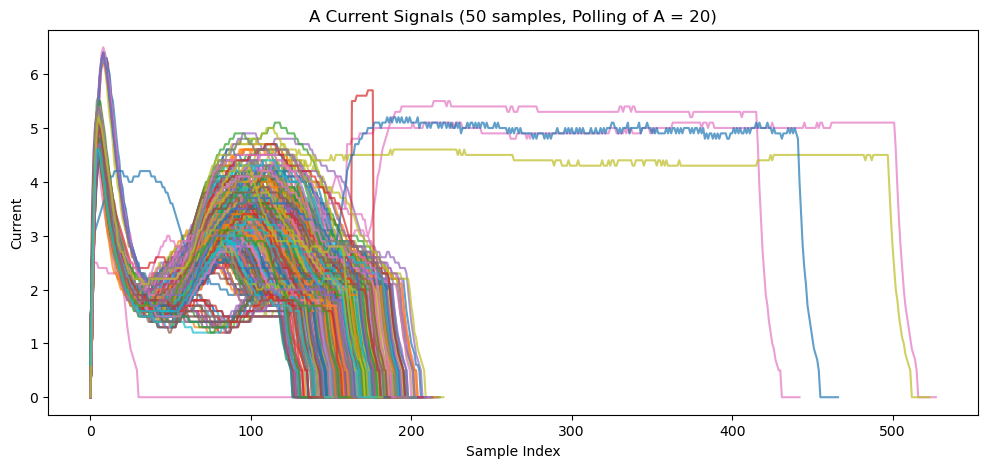

In [8]:
import matplotlib.pyplot as plt

# Filter for Polling of A = 100
df_poll_20 = df[df["Polling of A"] == 20]

# Sample 50 rows from each

sample_20 = df_poll_20.sample(n = 500, random_state=42)

# Plot for Polling of A = 20
plt.figure(figsize=(12, 5))
for idx, row in sample_20.iterrows():
    signal = [float(x.strip()) for x in row["A Current"].split(",")]
    plt.plot(signal, alpha=0.7)
plt.title("A Current Signals (50 samples, Polling of A = 20)")
plt.xlabel("Sample Index")
plt.ylabel("Current")
plt.show()

# # Plot for Polling of B = 20

# plt.figure(figsize=(12, 5))
# for idx, row in sample_20.iterrows():
#     signal = [float(x.strip()) for x in row["B Current"].split(",")]
#     plt.plot(signal, alpha=0.7)
# plt.title("B Current Signals (50 samples, Polling of B = 20)")
# plt.xlabel("Sample Index")
# plt.ylabel("Current")
# plt.show()


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def parse_signal_data(signal_string):
    """Parse comma-separated signal data string into numpy array"""
    try:
        values = [float(x) for x in signal_string.split(',')]
        return np.array(values)
    except:
        return np.array([])

def get_signal_length(signal_array):
    """Get the length of non-zero signal (excluding trailing zeros)"""
    # Find the last non-zero value
    non_zero_indices = np.where(signal_array > 0)[0]
    if len(non_zero_indices) == 0:
        return 0
    return non_zero_indices[-1] + 1

def is_signal_normal(signal_array, max_value_threshold=7.0, max_length=220):
    """
    Check if a signal is normal based on:
    1. Maximum value threshold
    2. Signal length
    3. Signal variation (to detect flat/straight lines)
    """
    if len(signal_array) == 0:
        return False
    
    # Check maximum value
    if np.max(signal_array) > max_value_threshold:
        return False
    
    # Check signal length (non-zero portion)
    signal_length = get_signal_length(signal_array)
    if signal_length > max_length:
        return False
    
    # Check if signal has reasonable variation (not a flat line)
    # Get non-zero portion of signal
    non_zero_signal = signal_array[signal_array > 0]
    if len(non_zero_signal) < 3:  # Too short to analyze
        return False
    
    # Calculate standard deviation of non-zero values
    signal_std = np.std(non_zero_signal)
    signal_mean = np.mean(non_zero_signal)
    
    # If coefficient of variation is too low, it might be a flat line
    if signal_mean > 0:
        cv = signal_std / signal_mean
        if cv < 0.1:  # Less than 10% variation
            return False
    
    return True

def filter_signal_data(csv_file_path, output_file_path=None):
    """
    Filter the CSV file to keep only normal signals
    """
    # Read the CSV file
    df = pd.read_csv(csv_file_path)
    
    print(f"Original dataset shape: {df.shape}")
    
    # Create a mask for normal signals
    normal_mask = []
    
    for index, row in df.iterrows():
        # Parse current signals
        a_current = parse_signal_data(row['A Current'])
        b_current = parse_signal_data(row['B Current'])
        
        # Check if both A and B currents are normal
        a_normal = is_signal_normal(a_current)
        b_normal = is_signal_normal(b_current)
        
        # Keep row only if both signals are normal
        is_normal = a_normal and b_normal
        normal_mask.append(is_normal)
        
        if not is_normal:
            print(f"Removing row {index}: A_max={np.max(a_current):.1f}, B_max={np.max(b_current):.1f}, "
                  f"A_len={get_signal_length(a_current)}, B_len={get_signal_length(b_current)}")
    
    # Filter the dataframe
    filtered_df = df[normal_mask].copy()
    
    print(f"Filtered dataset shape: {filtered_df.shape}")
    print(f"Removed {len(df) - len(filtered_df)} rows")
    
    # Save filtered data
    if output_file_path is None:
        output_file_path = csv_file_path.replace('.csv', '_filtered.csv')
    
    filtered_df.to_csv(output_file_path, index=False)
    print(f"Filtered data saved to: {output_file_path}")
    
    return filtered_df

def plot_filtered_signals(df, max_plots=10):
    """
    Plot the first few filtered signals to verify filtering
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    count = 0
    for index, row in df.iterrows():
        if count >= max_plots:
            break
            
        a_current = parse_signal_data(row['A Current'])
        b_current = parse_signal_data(row['B Current'])
        
        ax1.plot(a_current, alpha=0.7, label=f'Row {index}')
        ax2.plot(b_current, alpha=0.7, label=f'Row {index}')
        
        count += 1
    
    ax1.set_title('Filtered A Current Signals')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Current')
    ax1.grid(True)
    
    ax2.set_title('Filtered B Current Signals')
    ax2.set_xlabel('Sample Index')
    ax2.set_ylabel('Current')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()



Original dataset shape: (9865, 12)
Removing row 54: A_max=5.0, B_max=6.4, A_len=174, B_len=492
Removing row 87: A_max=5.2, B_max=8.3, A_len=130, B_len=170
Removing row 106: A_max=4.9, B_max=49.3, A_len=167, B_len=152
Removing row 156: A_max=4.9, B_max=8.4, A_len=176, B_len=155
Removing row 260: A_max=7.7, B_max=5.0, A_len=166, B_len=151
Removing row 264: A_max=8.2, B_max=5.1, A_len=151, B_len=170
Removing row 278: A_max=4.9, B_max=634.6, A_len=166, B_len=149
Removing row 298: A_max=4.9, B_max=3.1, A_len=336, B_len=128
Removing row 358: A_max=4.6, B_max=4.7, A_len=499, B_len=157
Removing row 408: A_max=4.9, B_max=5.1, A_len=150, B_len=508
Removing row 547: A_max=6.2, B_max=5.1, A_len=438, B_len=161
Removing row 590: A_max=5.3, B_max=7.8, A_len=155, B_len=161
Removing row 619: A_max=5.2, B_max=7.9, A_len=154, B_len=158
Removing row 852: A_max=5.9, B_max=4.6, A_len=438, B_len=159
Removing row 977: A_max=4.9, B_max=5.7, A_len=166, B_len=441
Removing row 1048: A_max=5.9, B_max=2.9, A_len=34

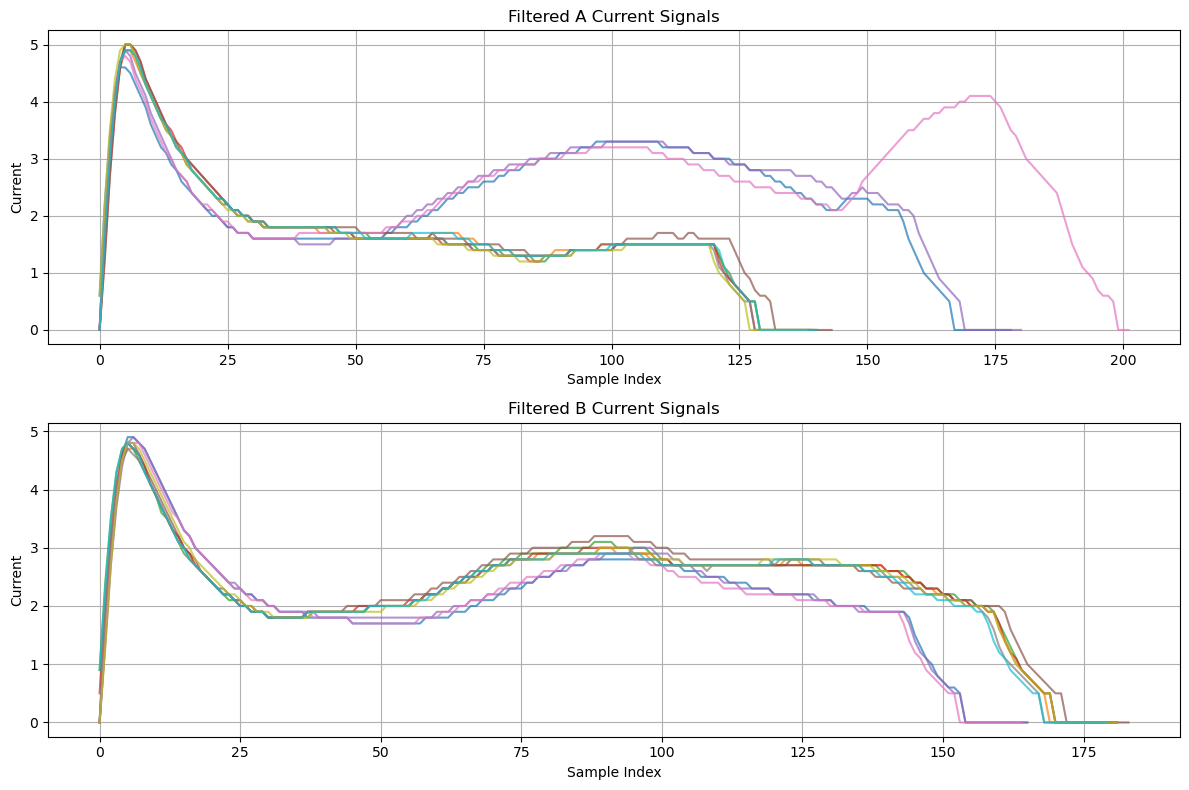


Filtered dataset statistics:
Row 0: A_max=4.6, B_max=4.9, A_len=167, B_len=154
Row 1: A_max=4.9, B_max=4.7, A_len=129, B_len=169
Row 2: A_max=5.0, B_max=4.8, A_len=129, B_len=170
Row 3: A_max=5.0, B_max=4.8, A_len=128, B_len=170
Row 4: A_max=4.9, B_max=4.9, A_len=169, B_len=154
Row 5: A_max=5.0, B_max=4.8, A_len=132, B_len=172
Row 6: A_max=4.8, B_max=4.8, A_len=199, B_len=153
Row 7: A_max=4.9, B_max=4.7, A_len=128, B_len=168
Row 8: A_max=5.0, B_max=4.8, A_len=127, B_len=170
Row 9: A_max=4.9, B_max=4.8, A_len=129, B_len=168
Row 10: A_max=4.9, B_max=4.9, A_len=127, B_len=167
Row 11: A_max=4.7, B_max=4.9, A_len=164, B_len=155
Row 12: A_max=5.0, B_max=4.8, A_len=133, B_len=19
Row 13: A_max=5.0, B_max=4.7, A_len=135, B_len=174
Row 14: A_max=5.0, B_max=4.6, A_len=136, B_len=172
Row 15: A_max=5.0, B_max=4.6, A_len=136, B_len=172
Row 16: A_max=4.7, B_max=4.8, A_len=171, B_len=155
Row 17: A_max=4.8, B_max=4.8, A_len=169, B_len=152
Row 18: A_max=4.9, B_max=4.7, A_len=128, B_len=169
Row 19: A_ma

In [12]:
# Main execution
if __name__ == "__main__":
    
    csv_file_path = '/Users/anamikasaroha/Energy7/week_10/NFR_poll_20.csv'
    
    # Filter the data
    filtered_df = filter_signal_data(csv_file_path)
    
    # Plot the filtered signals to verify
    plot_filtered_signals(filtered_df)
    
    # Additional statistics
    print("\nFiltered dataset statistics:")
    for index, row in filtered_df.iterrows():
        a_current = parse_signal_data(row['A Current'])
        b_current = parse_signal_data(row['B Current'])
        
        print(f"Row {index}: A_max={np.max(a_current):.1f}, B_max={np.max(b_current):.1f}, "
              f"A_len={get_signal_length(a_current)}, B_len={get_signal_length(b_current)}")